In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import roc_curve, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras import layers

c:\Users\Berna\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
higgs = pd.read_parquet('../data/processed/higgs_with_features.parquet')
qcd = pd.read_parquet('../data/processed/qcd_with_features.parquet')

In [4]:
features = [
    'pt_lead', 'pt_sublead',
    'eta_lead', 'eta_sublead',
    'phi_lead', 'phi_sublead',
    'ptcone20_lead', 'ptcone20_sublead',
    'topoetcone20_lead', 'topoetcone20_sublead',
    'topoetcone40_lead', 'topoetcone40_sublead',
    'f1_lead', 'f1_sublead',
    'delta_r', 'delta_phi', 'delta_eta',
    'pt_ratio', 'pt_asymmetry', 'pt_sum',
]

In [5]:
higgs['label'] = 1
qcd['label'] = 0

In [6]:
data = pd.concat([higgs, qcd], ignore_index=True)

data= data.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
print(f"Total events: {len(data)}")
print(f"Signal events: {len(higgs)}")
print(f"Background events: {len(qcd)}")

Total events: 138311
Signal events: 78112
Background events: 60199


In [8]:
X = data[features]
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

Training set: 110648
Test set: 27663


In [9]:
from sklearn.preprocessing import StandardScaler

# Scaler oluştur
scaler = StandardScaler()

# Train data ile fit et ve transform et
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# DataFrame'e çevir (opsiyonel, ama isimleri korur)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print("Scaling completed!")

Scaling completed!


In [10]:
# Model mimarisi
model_nn = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    layers.Dense(128, activation='relu'),
    layers. Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers. Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers. Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_nn. compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Early stopping
early_stopping = keras.callbacks. EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    mode='max'
)

# Eğitim
history = model_nn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

# Test değerlendirmesi
y_pred_proba_nn = model_nn. predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

print(f"\n=== Sonuçlar ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"ROC AUC:    {roc_auc_score(y_test, y_pred_proba_nn):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_nn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

Epoch 1/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7592 - auc: 0.8259 - loss: 0.4954 - val_accuracy: 0.8917 - val_auc: 0.9327 - val_loss: 0.3042
Epoch 2/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8849 - auc: 0.9263 - loss: 0.3097 - val_accuracy: 0.9089 - val_auc: 0.9461 - val_loss: 0.2573
Epoch 3/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9006 - auc: 0.9405 - loss: 0.2745 - val_accuracy: 0.9110 - val_auc: 0.9511 - val_loss: 0.2440
Epoch 4/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9068 - auc: 0.9450 - loss: 0.2609 - val_accuracy: 0.9126 - val_auc: 0.9523 - val_loss: 0.2419
Epoch 5/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9102 - auc: 0.9484 - loss: 0.2492 - val_accuracy: 0.9156 - val_auc: 0.9553 - val_loss: 0.2345
Epoch 6/100
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9116 - auc: 0.9503 - loss: 0.2445 - val_accuracy: 0.9155 - val_auc: 0.9552 - val_loss: 0.2336
Epoch 7/100
346/346 ━━━━━━━━━━━━━━

In [11]:
# Train seti değerlendirmesi
y_train_pred_proba_nn = model_nn.predict(X_train_scaled).flatten()

train_auc = roc_auc_score(y_train, y_train_pred_proba_nn)
test_auc = roc_auc_score(y_test, y_pred_proba_nn)

train_acc = accuracy_score(y_train, (y_train_pred_proba_nn >= 0.5).astype(int))
test_acc = accuracy_score(y_test, y_pred_nn)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:    {test_auc:.4f}")
print(f"Fark:        {train_auc - test_auc:.4f}")
print()
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Fark:           {train_acc - test_acc:.4f}")

3458/3458 ━━━━━━━━━━━━━━━━━━━━ 2s 534us/step
Train AUC: 0.9661
Test AUC:    0.9625
Fark:        0.0036

Train Accuracy: 0.9267
Test Accuracy:  0.9227
Fark:           0.0040


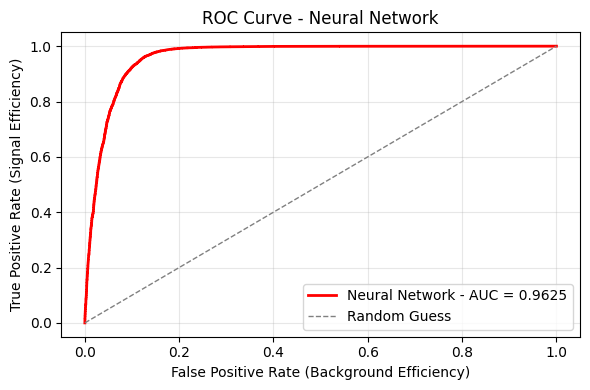

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib. pyplot as plt

# ROC curve hesapla
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_proba_nn)
auc_nn = roc_auc_score(y_test, y_pred_proba_nn)

# Görselleştirme
plt.figure(figsize=(6, 4))
plt.plot(fpr_nn, tpr_nn, color='red', lw=2, 
         label=f'Neural Network - AUC = {auc_nn:.4f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', 
         label='Random Guess')

plt.xlabel('False Positive Rate (Background Efficiency)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('ROC Curve - Neural Network')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_nn.png', dpi=300)
plt.show()